<a href="https://colab.research.google.com/github/fiametahagos07/CSCE-5575-HW-2-Template/blob/master/Logistic_Regression_Car_Assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Week 11: Assignment 4 - Logistic Regression Assignment (Age & Salary → Purchased)
**Coures:** INFO 4670 Fengjiao Tu  
**Goal:** Train and evaluate a Logistic Regression model to predict whether a customer purchases a car using `Age` and `Salary`.

---

## I. Assignment Objective
By completing this assignment, you will:
- Understand the concept and intuition of logistic regression.
- Load and preprocess data using `pandas`.
- Train and evaluate a logistic regression model with `scikit-learn`.
- Visualize classification results.
- Analyze model performance and reflect on possible improvements.


## II. Dataset Description
Expected CSV file name: **`car_purchase_data.csv`**

| Column | Description | Example |
|--------|-------------|---------|
| `Age` | Age of the customer | 35 |
| `Salary` | Annual or monthly income | 60000 |
| `Purchased` | Whether the customer purchased a car (1 = Yes, 0 = No) | 1 |


---
# Grading Rubric (Total = 100 points)

| Section | Description | Points | Details |
|--------|-------------|--------|---------|
| **Objective Understanding** | Explain purpose and logic of logistic regression | 10 | Goal & rationale (5); why LR for this task (5) |
| **Data Preparation** | Data loading, splitting, scaling | 20 | Import & preview (5); X/y split (5); train/test (5); scaling (5) |
| ** Model Training & Evaluation** | Fit, predict, metrics, visualization | 40 | Trained correctly (10); metrics shown (10); **accuracy ≥ 87.5% (10)**; visualization (10) |
| ** Analysis & Reflection** | Interpretation and critical thinking | 30 | Probability→class explanation (10); result discussion (10); improvements (10) |


**Accuracy Requirement:**
- Full credit (10 pts) if **accuracy ≥ 87.5%**
- Partial (7–9 pts) if **80% ≤ accuracy < 87.5%**
- Minimal (≤5 pts) if **accuracy < 80%**
- 0 pts if the model fails to run


## III. Steps to Complete
Follow the cells below in order. According to the hands-on task, please complete the code.

In [2]:
from google.colab import files
uploaded = files.upload()

Saving car_purchase_data.csv to car_purchase_data.csv


### Step 1: Import libraries and load data

In [3]:
#Please write the code here

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report

# Load dataset
data = pd.read_csv('car_purchase_data.csv')

# Preview data
display(data.head())
print('Shape:', data.shape)
print(data.info())
print(data.isnull().sum())

,User ID,Gender,Age,Salary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0


Shape: (400, 5)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   User ID    400 non-null    int64 
 1   Gender     400 non-null    object
 2   Age        400 non-null    int64 
 3   Salary     400 non-null    int64 
 4   Purchased  400 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 15.8+ KB
None
User ID      0
Gender       0
Age          0
Salary       0
Purchased    0
dtype: int64


### Step 2: Split features and target

In [4]:
#Please write the code here

X = data[['Age', 'Salary']].values
y = data['Purchased'].values

print('X shape:', X.shape)
print('y shape:', y.shape)
print('Class distribution:\n', pd.Series(y).value_counts())

X shape: (400, 2)
y shape: (400,)
Class distribution:
 0    257
1    143
Name: count, dtype: int64


### Step 3: Train/Test Split

In [5]:
#Please write the code here

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=0
)

print('Train size:', X_train.shape[0])
print('Test size:', X_test.shape[0])

Train size: 300
Test size: 100


### Step 4: Feature Scaling

In [6]:
#Please write the code here

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print('Feature scaling complete.')

Feature scaling complete.


### Step 5: Train Logistic Regression Model

In [7]:
#Please write the code here

model = LogisticRegression(random_state=0)
model.fit(X_train, y_train)

print('Model trained successfully.')

Model trained successfully.


### Step 6: Predict and Evaluate

In [8]:
#Please write the code here

y_pred = model.predict(X_test)

acc = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

print('Accuracy:', acc)
print('\nConfusion Matrix:\n', cm)
print('\nClassification Report:\n', classification_report(y_test, y_pred))

Accuracy: 0.89

Confusion Matrix:
 [[65  3]
 [ 8 24]]

Classification Report:
               precision    recall  f1-score   support

           0       0.89      0.96      0.92        68
           1       0.89      0.75      0.81        32

    accuracy                           0.89       100
   macro avg       0.89      0.85      0.87       100
weighted avg       0.89      0.89      0.89       100



### Step 7: Visualization of Decision Regions

/tmp/ipykernel_543/1408443686.py:23: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(


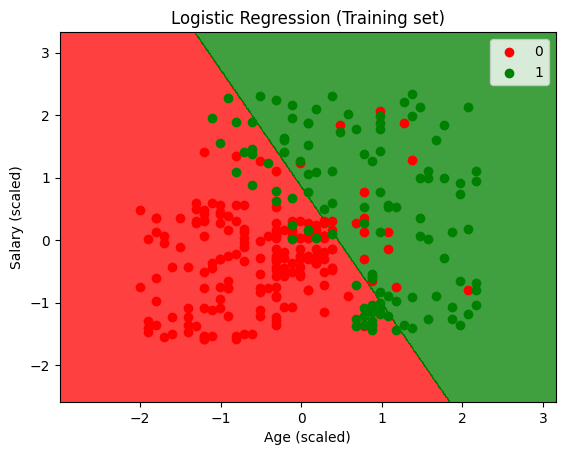

In [9]:
#Please write the code here

from matplotlib.colors import ListedColormap

X_set, y_set = X_train, y_train

X1, X2 = np.meshgrid(
    np.arange(start=X_set[:, 0].min() - 1, stop=X_set[:, 0].max() + 1, step=0.01),
    np.arange(start=X_set[:, 1].min() - 1, stop=X_set[:, 1].max() + 1, step=0.01)
)

plt.contourf(
    X1, X2,
    model.predict(np.array([X1.ravel(), X2.ravel()]).T).reshape(X1.shape),
    alpha=0.75,
    cmap=ListedColormap(('red', 'green'))
)

plt.xlim(X1.min(), X1.max())
plt.ylim(X2.min(), X2.max())

for i, j in enumerate(np.unique(y_set)):
    plt.scatter(
        X_set[y_set == j, 0],
        X_set[y_set == j, 1],
        c=ListedColormap(('red', 'green'))(i),
        label=j
    )

plt.title('Logistic Regression (Training set)')
plt.xlabel('Age (scaled)')
plt.ylabel('Salary (scaled)')
plt.legend()
plt.show()

## IV. Reflection Questions
1. Logistic regression outputs probabilities — why can it still be used for classification?
2. Based on your model, which customers are more likely to purchase a car?
3. What factors might cause low accuracy in this task?
4. Propose additional features or preprocessing steps that could improve accuracy.


#Please write your answer here

1. A probability between 0 and 1 has been calculated through logistic regression. We impose a threshold, often 0.5, so it can still be utilized for classification.   The customer is classified as 1 (Purchased) by the model if the anticipated probability is 0.5 or higher. If not, the customer will be classified as 0 (Not Purchased).

2. Customers in specific age groups and those with greater incomes are more likely to buy a car, according to the model. Generally speaking, the likelihood of a purchase rises with earnings. Depending on the dataset's trend, age may also have an impact on the choice.

3. Limited details, noisy data, missing values, outliers, class imbalance, or contact between buyers and non-buyers may all relate to low accuracy. Performance can also be lowered by a weak train-test split.

4. Variables like gender, occupation, education level, family size, credit score, and location could increase accuracy. Performance may also be improved by methods for preprocessing like managing outliers, balancing classes, and adjusting model parameters.

